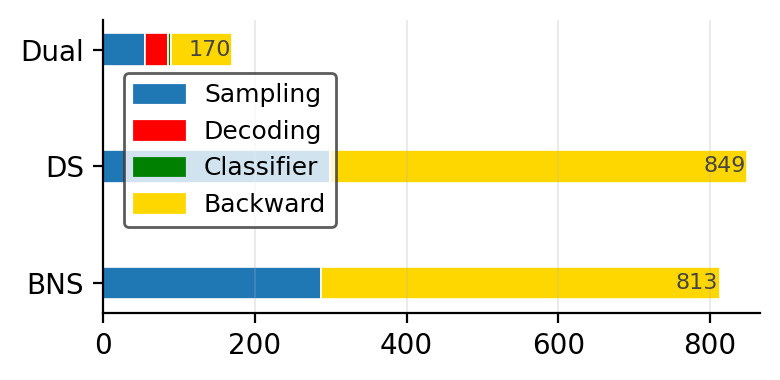

In [2]:
# FIX: keep "Dual" aligned with the "Dual" row.
# Minimal change: iterate in the SAME order as the tick labels.
# (Changed `for idx, solver in enumerate(labels[::-1]):` -> `for idx, solver in enumerate(labels):`)

import numpy as np
import matplotlib.pyplot as plt

def draw_dit(
    dual_times, ds_times, bns_times,
    *, figsize=(4, 2), dpi=200,
    bar_height=0.28, grid=True, grid_alpha=0.3,
    total_inside=True, total_pad=2.0, total_fs=8,
    legend_mode="fig",            # "fig" | "ax" | "none"
    legend_kwargs=None,           # e.g., {"loc":"center", "bbox_to_anchor":(0.3,0.6), ...}
    colors=None,
    rc_update=None,
):
    if colors is None:
        colors = {"Sampling":"#1f77b4","Decoding":"red","Classifier":"green","Backward":"gold"}
    if rc_update is None:
        rc_update = {
            "figure.dpi": dpi, "font.size": 10,
            "axes.titlesize": 11, "axes.labelsize": 10,
            "mathtext.fontset": "cm", "axes.linewidth": 0.8, "grid.alpha": grid_alpha,
        }
    plt.rcParams.update(rc_update)

    comps = ["Sampling","Decoding","Classifier","Backward"]
    # preserve the intended order
    labels = ["Dual", "DS", "BNS"]
    rows  = {"Dual": dual_times, "DS": ds_times, "BNS": bns_times}

    fig, ax = plt.subplots(figsize=figsize)

    # keep your spine change
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # y positions: reversed so Dual appears at top, but we iterate labels in-order
    y = np.arange(len(labels))[::-1]   # [2,1,0]

    totals = []
    for idx, solver in enumerate(labels):  # <---- FIX: iterate in the same order as labels
        times = rows[solver]
        left = 0.0
        for comp, w in zip(comps, times):
            if w <= 0:
                continue
            ax.barh(y[idx], w, height=bar_height, left=left,
                    color=colors[comp], edgecolor="white", linewidth=0.6)
            left += w
        totals.append(left)
        if total_inside:
            tx = max(0, left - total_pad)
            ax.text(tx, y[idx], f"{int(round(left))}", va="center", ha="right",
                    fontsize=total_fs, color="#444444", clip_on=True)

    # Axis cosmetics
    ax.set_yticks(y)
    ax.set_yticklabels(labels)   # matches plotting order
    #ax.set_xlabel("Time per training step (ms)")
    if grid:
        ax.grid(axis="x", linestyle="-", linewidth=0.6)
    if totals:
        ax.set_xlim(0, max(totals) * 1.02)

    # Legend — pass-through
    if legend_mode != "none":
        handles = [plt.Rectangle((0,0),1,1,color=colors[k]) for k in comps]
        legend_kwargs = legend_kwargs or {}
        if legend_mode == "fig":
            fig.legend(handles, comps, **legend_kwargs)
        elif legend_mode == "ax":
            ax.legend(handles, comps, **legend_kwargs)

    plt.tight_layout()
    plt.show()


# Example (same values)
dual_times = [55, 30, 5, 80]
ds_times   = [299.71, 0, 0, 549.43]
bns_times  = [286.64, 0, 0, 526.21]

draw_dit(
    dual_times, ds_times, bns_times,
    legend_mode="fig",
    legend_kwargs={
        "loc": "center",
        "bbox_to_anchor": (0.3, 0.6),
        "frameon": True, "fancybox": True,
        "edgecolor": "#333333", "facecolor": "white",
        "ncol": 1, "prop": {"size": 9}
    }
)


In [59]:
PALETTES_PRO = {
    # 1) IEEE-Classic (짙은 대비, 안전한 조합)
    "ieee_classic": {
        "Sampling":  "#1F4E79",  # deep blue
        "Decoding":  "#B22222",  # firebrick
        "Classifier":"#2E7D32",  # forest green
        "Backward":  "#B58900",  # goldenrod
    },

    # 2) Nature-Subdued (자연스러운 톤, 인쇄 친화)
    "nature_subdued": {
        "Sampling":  "#2C5AA0",  # academic blue
        "Decoding":  "#A2322D",  # brick red
        "Classifier":"#2F7D4E",  # leaf green
        "Backward":  "#A67C00",  # mustard ochre
    },

    # 3) Okabe–Ito Deep (색각이상 안전 팔레트의 딥톤 변형)
    "okabe_ito_deep": {
        "Sampling":  "#1B63A5",  # deep azure
        "Decoding":  "#C03A00",  # deep vermilion
        "Classifier":"#0F8D5C",  # bluish green (deep)
        "Backward":  "#B39B00",  # deep mustard
    },

    # 4) Brewer-Professional (ColorBrewer 계열의 논문형)
    "brewer_professional": {
        "Sampling":  "#377EB8",  # brewer blue
        "Decoding":  "#D95F02",  # orange-red
        "Classifier":"#1A9850",  # medium green
        "Backward":  "#E6AB02",  # warm mustard
    },

    # 5) Journal-PrintSafe (그레이스케일 분리도↑, 채도 과하지 않음)
    "journal_printsafe": {
        "Sampling":  "#2A4B8D",  # navy-ish blue
        "Decoding":  "#8C2D04",  # burnt umber
        "Classifier":"#2B8A3E",  # deep green
        "Backward":  "#A07900",  # ochre
    },
}


okabe_ito


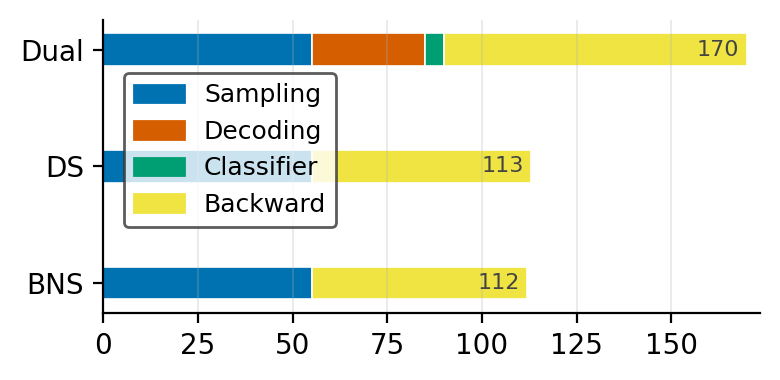

vibrant


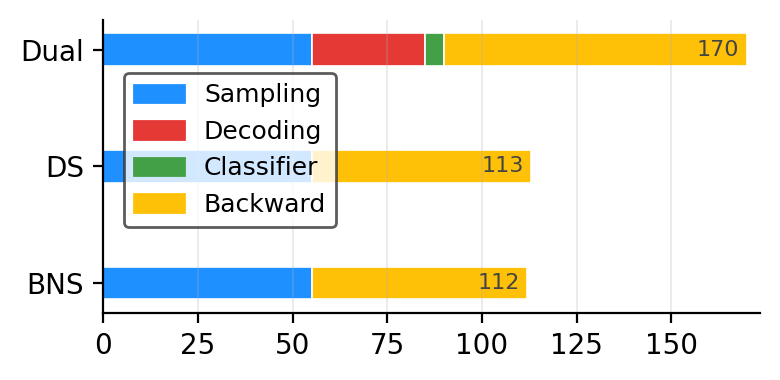

muted


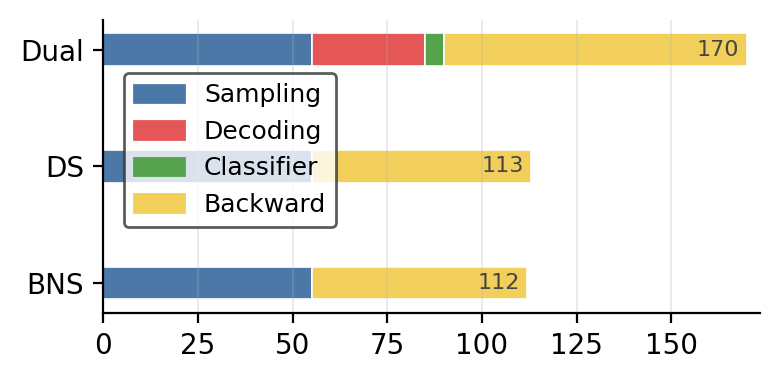

deep_contrast


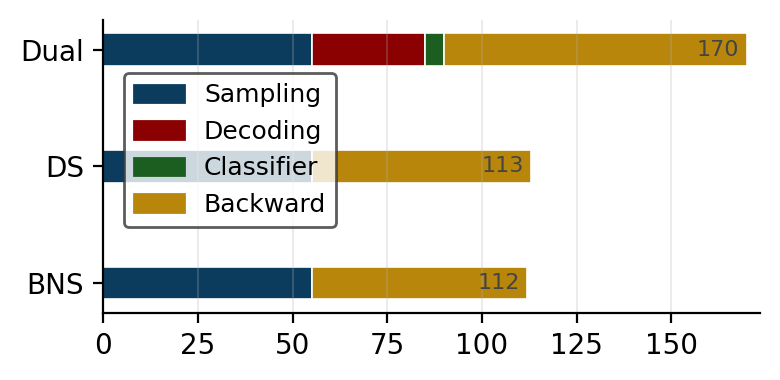

pastel


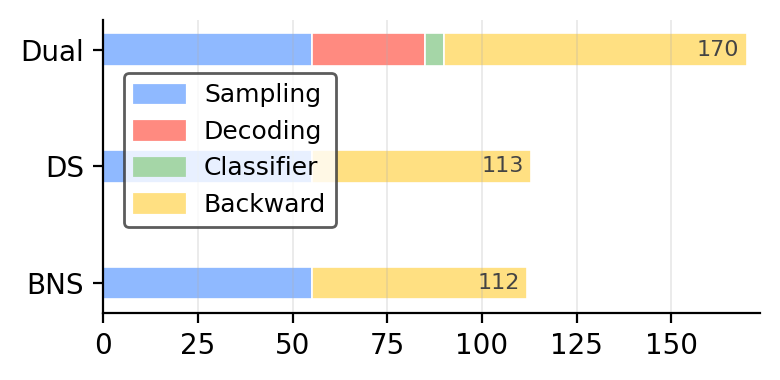

neon


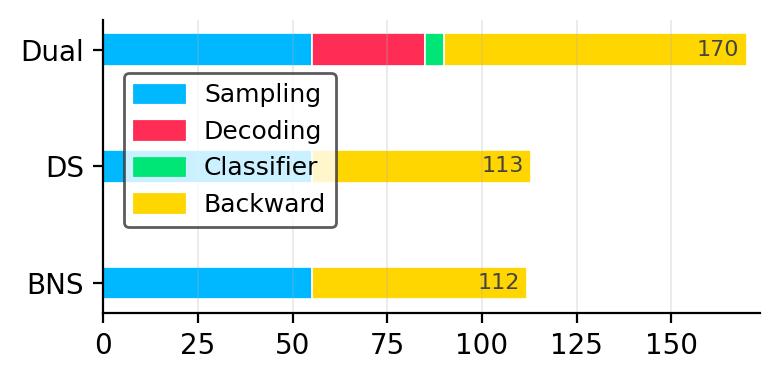

print_safe


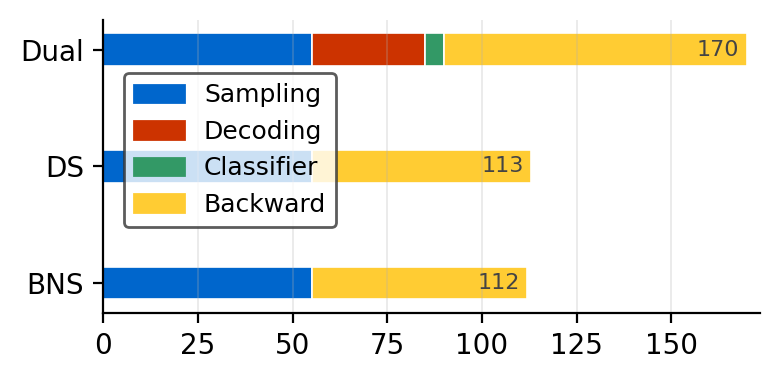

earthy


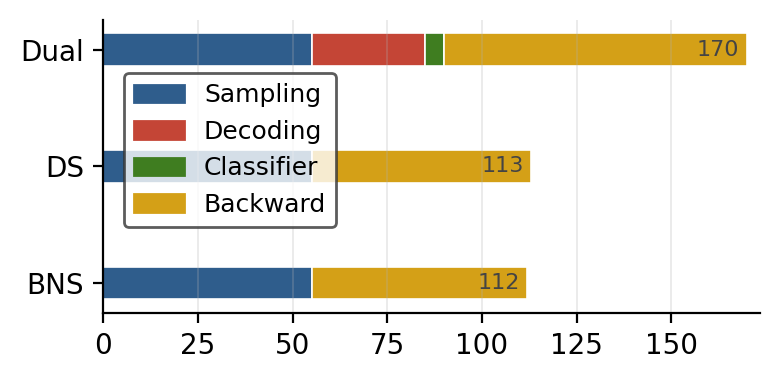

coolwarm_variant


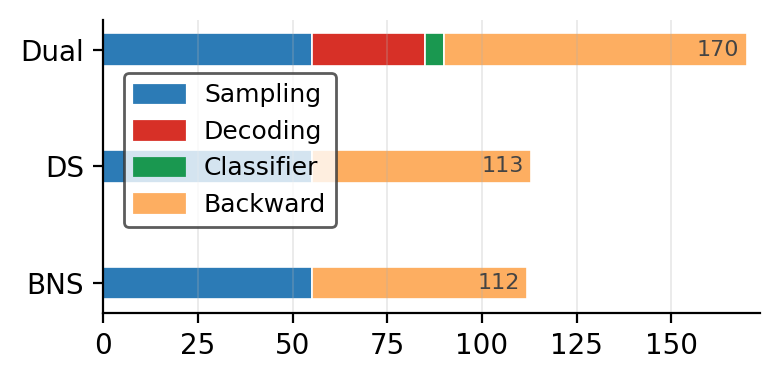

tableau_alt


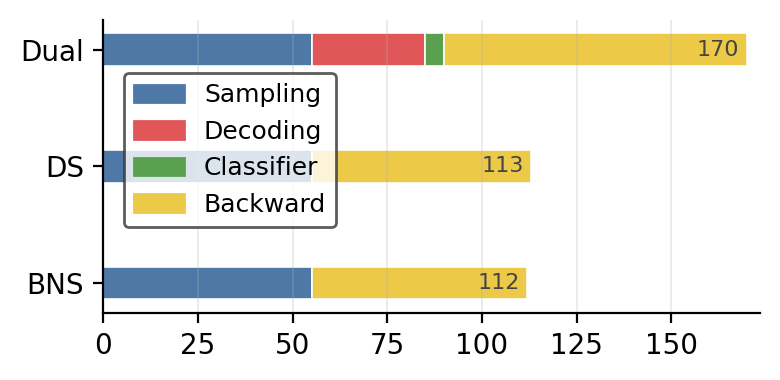

In [60]:
from turtle import color


for key in PALETTES.keys():
    print(key)
    draw_dit(
        dual_times, ds_times, bns_times,
        legend_mode="fig",
        legend_kwargs={
            "loc": "center",
            "bbox_to_anchor": (0.3, 0.6),  # YOUR placement (we won't override)
            "frameon": True, "fancybox": True,
            "edgecolor": "#333333", "facecolor": "white",
            "ncol": 1, "prop": {"size": 9}
        },
        colors=PALETTES[key]
    )
